# 📊 Amazon Bestsellers Analysis (2009–2019)

This project analyzes Amazon's bestselling books to uncover patterns in ratings, prices, and popularity.

The objective is to explore:
- Trends over time
- Differences between genres
- Factors influencing book popularity


The first step is to import the library used for pre-processing and cleaning the dataset. Here, we must look at:

*   Null data
*   Duplicated information
*   Mispelled words




In [ ]:
import pandas as pd
df_book = pd.read_csv("bestsellers with categories.csv" , encoding = "utf-8-sig")
# Viewing the revelant information of our dataset:
df_book.info

<bound method DataFrame.info of                                                   Name  \
0                        10-Day Green Smoothie Cleanse   
1                                    11/22/63: A Novel   
2              12 Rules for Life: An Antidote to Chaos   
3                               1984 (Signet Classics)   
4    5,000 Awesome Facts (About Everything!) (Natio...   
..                                                 ...   
545       Wrecking Ball (Diary of a Wimpy Kid Book 14)   
546  You Are a Badass: How to Stop Doubting Your Gr...   
547  You Are a Badass: How to Stop Doubting Your Gr...   
548  You Are a Badass: How to Stop Doubting Your Gr...   
549  You Are a Badass: How to Stop Doubting Your Gr...   

                       Author  User Rating  Reviews  Price  Year        Genre  
0                    JJ Smith          4.7    17350      8  2016  Non Fiction  
1                Stephen King          4.6     2052     22  2011      Fiction  
2          Jordan B. Peterson  

In [ ]:
# This code is used to view the null data:
df_book.isnull().sum()

Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

In [ ]:
# This code is used to view the duplicated data:
df_book.duplicated().sum()

np.int64(0)

In [ ]:
df_book.describe()

,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


In [ ]:
df_book.columns

Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')

In [ ]:
df_book.rename (columns = {"Name": "Title" , "Year": "Publication year" , "User Rating" : "Rating" }, inplace=True)

In [ ]:
df_book.columns

Index(['Title', 'Author', 'Rating', 'Reviews', 'Price', 'Publication year',
       'Genre'],
      dtype='object')

# **Analysis:**

In [ ]:
top_authors = df_book["Author"].value_counts().head(5)
print(top_authors)

Author
Jeff Kinney                           12
Gary Chapman                          11
Rick Riordan                          11
Suzanne Collins                       11
American Psychological Association    10
Name: count, dtype: int64


According to the analysis, the results indicate that the author with the highest score is Jeff Kinney. Jeff Kinney became extremely popular on Amazon primarily because of his Diary of a Wimpy Kid series, which hit several factors that drive strong book sales:


*   Relatable stories for kids
*   Easy and fun to read
*   Strong online beginnings
*   Consistent releases
*   Massive bestseller performance
*   Amazon's ecosystem amplified success






In [ ]:
top_book = df_book["Title"].value_counts().head(5)
print(top_book)

Title
Publication Manual of the American Psychological Association, 6th Edition       10
StrengthsFinder 2.0                                                              9
Oh, the Places You'll Go!                                                        8
The Very Hungry Caterpillar                                                      7
The 7 Habits of Highly Effective People: Powerful Lessons in Personal Change     7
Name: count, dtype: int64


The book with the highest score was "Publication Manual of the American Psychological Association, 6th Edition". The reason behind its success is The book was the authoritative source for APA formatting and citation rules. Universities, colleges, journals, and professional organizations required students and researchers to follow APA style, creating a large and recurring audience. Also, millions of students were required to buy it. Other reasons are:

*   The timing coincided with growth in higher education
*   It solved a high-frequency problem
*   Amazon was becoming the default textbook marketplace








In [ ]:
reviews_per_title = df_book.groupby("Title")["Reviews"].value_counts().head(5)
print(reviews_per_title)

Title                                                               Reviews
10-Day Green Smoothie Cleanse                                       17350      1
11/22/63: A Novel                                                   2052       1
12 Rules for Life: An Antidote to Chaos                             18979      1
1984 (Signet Classics)                                              21424      1
5,000 Awesome Facts (About Everything!) (National Geographic Kids)  7665       1
Name: count, dtype: int64


In reviews, "1984 (Signet Classics)" has the highest score. History books often generate a lot of reviews because they combine education, storytelling, identity, and debate in ways that encourage readers to share their opinions.





In [ ]:
average_rating_by_genre = df_book.groupby ("Genre")["Rating"].mean()
print(average_rating_by_genre)

Genre
Fiction        4.648333
Non Fiction    4.595161
Name: Rating, dtype: float64


# Visualization:

- The first chart illustrates the difference between each Genre performance.

- The second chart presents Top Writers of that decade.

- The third chart reveals a comparison of the reviews received by the Top 3 Books.

- The fourth chart shows the asymmetry and symmetry between Genres and its reviews.


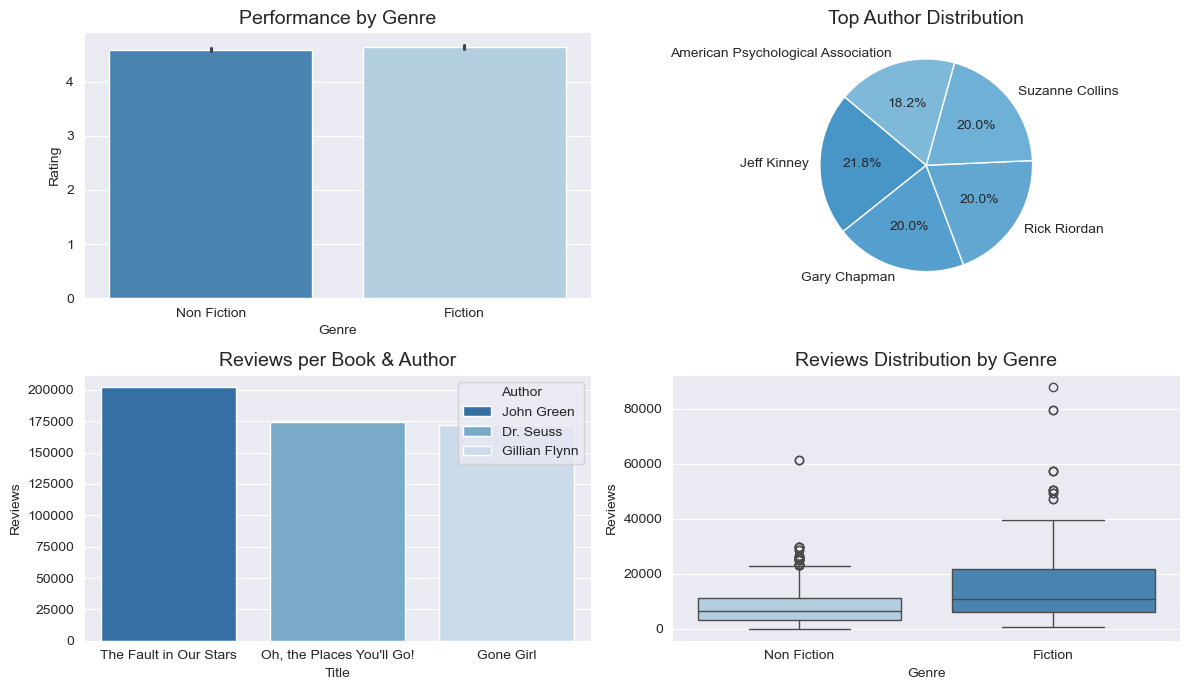

In [ ]:
# Graphic 1 (barplot)
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 2, figsize=(12,7))

sns.set_style("darkgrid")
sns.barplot(
    x="Genre",
    y="Rating",
    hue="Genre",
    data=df_book,
    palette="Blues_r",
    legend=False,
    ax=ax[0,0]
)
ax[0,0].set_title("Performance by Genre" , fontsize=14)

# Graphic 2 (pie)
ax[0,1].pie(
    top_authors,
    labels=top_authors.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Blues_r(range(100, 100 + len(top_authors)*10, 10))
)
ax[0,1].set_title("Top Author Distribution" , fontsize=14)

# Grafic 3 (barplot)

top_books = (df_book.groupby(["Title", "Author"], as_index=False)["Reviews"]
             .sum()
             .sort_values("Reviews", ascending=False)
             .head(3))

sns.barplot(
    data=top_books,
    x="Title",
    y="Reviews",
    hue="Author",
    palette="Blues_r",
    ax=ax[1,0]

)
ax[1,0].set_title("Reviews per Book & Author" , fontsize=14)


sns.boxplot(
    data=df_book,
    x="Genre",
    y="Reviews",
    hue="Genre",
    palette="Blues" ,
    ax=ax[1,1]
)

ax[1,1].set_title("Reviews Distribution by Genre", fontsize=14)



plt.tight_layout()
plt.show()

**Key insights:**
- Most bestselling books have consistently high ratings (~4.5–5.0).
- Reviews are highly skewed, with a small number of books dominating attention.
- There is no strong correlation between price and rating.
- Fiction and Non Fiction show similar rating patterns.




**Author:** Suny Brunoldi